<a href="https://colab.research.google.com/github/JasonL888/AI_Experiments/blob/main/ReinforcementLearning/hands_on_part_1_classic_q-learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-on Part 1 - Classic Q-Learning
- using the gymnasium Frozen Lake
    - ![Frozen Lake](https://gymnasium.farama.org/_images/frozen_lake.gif)
        - Credit: image from https://gymnasium.farama.org

## Colab Rendering Setup

In [1]:
# Install required packages for rendering on Colab
!pip install pyvirtualdisplay pyglet 'gymnasium[classic_control]'
!apt-get install -y xvfb python-opengl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.4 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package python-opengl


In [2]:
import os
from pyvirtualdisplay import Display
from IPython.display import HTML
from base64 import b64encode

# Start virtual display
# This is necessary because gymnasium environments with visual render_mode
# (like 'rgb_array' for FrozenLake) often rely on a graphical backend.
display = Display(visible=0, size=(1400, 900))
display.start()

# Helper function to display a video in Colab
def show_video(video_path):
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML("""
    <video width=400 controls>
          <source src="%s" type="video/mp4">
    </video>
    """ % data_url)

print("Virtual Display running and video helper function defined.")

Virtual Display running and video helper function defined.


## Setup and Imports

In [3]:
!pip install "gymnasium[toy-text]"

In [4]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import pygame

## Environment Setup

In [5]:
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="ansi")
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)

Action space: Discrete(4)
Observation space: Discrete(16)


## Initialize Q-table

In [6]:
state_size = env.observation_space.n
action_size = env.action_space.n
qtable = np.zeros((state_size, action_size))
print("Q-table shape:", qtable.shape)
print("Initial Q-table:")
print(qtable)

Q-table shape: (16, 4)
Initial Q-table:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


## Q-learning Parameters

In [7]:
learning_rate = 0.8
discount_factor = 0.95
epochs = 1000
epsilon = 1.0
max_epsilon = 1.0
min_epsilon = 0.01
decay_rate = 0.001

## Training Loop with Live Updates

In [8]:
rewards = []

for episode in range(epochs):
    state, info = env.reset()
    total_rewards = 0

    while True:
        # Exploration vs Exploitation
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()  # Explore
        else:
            action = np.argmax(qtable[state, :])  # Exploit

        # Take action
        new_state, reward, terminated, truncated, info = env.step(action)

        # Q-learning update
        qtable[state, action] = qtable[state, action] + learning_rate * (
            reward + discount_factor * np.max(qtable[new_state, :]) - qtable[state, action]
        )

        total_rewards += reward
        state = new_state

        if terminated or truncated:
            break

    # Epsilon decay
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
    rewards.append(total_rewards)

    # Progress update every 100 episodes
    if episode % 100 == 0:
        #clear_output(wait=True)
        print(f"Episode: {episode}, Epsilon: {epsilon:.3f}")
        print(f"Success rate (last 100): {np.mean(rewards[-100:]):.2f}")

print("\nTraining completed!")

Episode: 0, Epsilon: 1.000
Success rate (last 100): 0.00
Episode: 100, Epsilon: 0.906
Success rate (last 100): 0.04
Episode: 200, Epsilon: 0.821
Success rate (last 100): 0.05
Episode: 300, Epsilon: 0.743
Success rate (last 100): 0.07
Episode: 400, Epsilon: 0.674
Success rate (last 100): 0.18
Episode: 500, Epsilon: 0.610
Success rate (last 100): 0.19
Episode: 600, Epsilon: 0.553
Success rate (last 100): 0.29
Episode: 700, Epsilon: 0.502
Success rate (last 100): 0.38
Episode: 800, Epsilon: 0.455
Success rate (last 100): 0.45
Episode: 900, Epsilon: 0.413
Success rate (last 100): 0.45

Training completed!


## Visualize Learning Progress

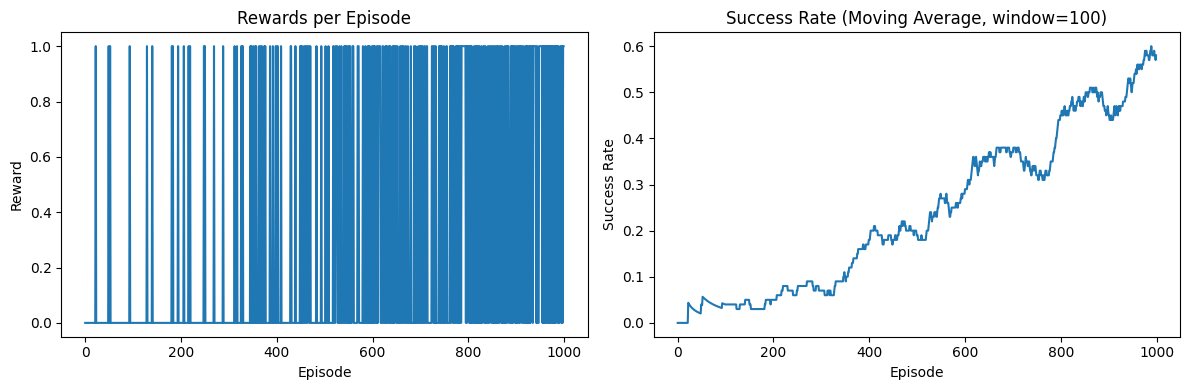

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(rewards)
plt.title("Rewards per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")

plt.subplot(1, 2, 2)
# Moving average
moving_avg = [np.mean(rewards[i-100:i]) if i >= 100 else np.mean(rewards[:i+1])
              for i in range(len(rewards))]
plt.plot(moving_avg)
plt.title("Success Rate (Moving Average, window=100)")
plt.xlabel("Episode")
plt.ylabel("Success Rate")

plt.tight_layout()
plt.show()

## Inspect the Final Q-table
- Each row = a state (0..15).
- Each column = an action (0..3) corresponding to ['←','↓','→','↑'] in your notebook.
- Each number = Q(s,a): the expected (discounted) return of taking that action in that state and following the learned policy afterward. Higher = better.

In [13]:
print("Final Q-table:")
print(qtable)

Final Q-table:
[[0.73509189 0.77378094 0.77378094 0.73509189]
 [0.73509189 0.         0.81450625 0.77378094]
 [0.77378094 0.857375   0.77378094 0.81450625]
 [0.81450625 0.         0.77378094 0.77378094]
 [0.77378094 0.81450625 0.         0.73509189]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.         0.81450625]
 [0.         0.         0.         0.        ]
 [0.81450625 0.         0.857375   0.77378094]
 [0.81450625 0.9025     0.9025     0.        ]
 [0.857375   0.95       0.         0.857375  ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.9025     0.95       0.857375  ]
 [0.9025     0.95       1.         0.9025    ]
 [0.         0.         0.         0.        ]]


In [12]:
# 1. Determine the best action index for every state
# axis=1 finds the index of the maximum value across each row (state)
best_actions = np.argmax(qtable, axis=1)

# 2. Map the action index to the corresponding symbol
# Action map: 0: Left (←), 1: Down (↓), 2: Right (→), 3: Up (↑)
action_symbols = np.array(['←', '↓', '→', '↑'])[best_actions]

# 3. Reshape the 16-element array into a 4x4 grid (the FrozenLake map size)
policy_grid = action_symbols.reshape(4, 4)

# 4. Print the grid
print("Optimal policy (4x4 grid representation):")
for row in policy_grid:
    print(' '.join(row))

Optimal policy (4x4 grid representation):
↓ → ↓ ←
↓ ← ↓ ←
→ ↓ ↓ ←
← → → ←


## Test the Trained Agent

In [11]:
## Visualization Loop (Corrected Cell)

# 1. Define the directory and filename pattern
video_dir = 'video'
video_prefix = 'q_learning_frozenlake'
video_filename = f"{video_prefix}-episode-0.mp4"
video_path = os.path.join(video_dir, video_filename)

# Make sure the video directory exists
os.makedirs(video_dir, exist_ok=True)

# 2. Create a new environment instance for recording
# We must use 'rgb_array' to get the frame data for video recording.
env_render = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")

# 3. Wrap the environment with the RecordVideo wrapper
# This saves the episode to the 'video' folder.
# We set episode_trigger to True to record the first episode.
env_render = gym.wrappers.RecordVideo(
    env_render,
    video_dir, # Use the directory path here
    episode_trigger=lambda episode: True,
    name_prefix=video_prefix # Optional: custom filename prefix
)

# Start the first (and only) episode we want to record
state, info = env_render.reset(seed=42)
total_rewards = 0
done = False
frame_count = 0

print("Running visualization episode...")

while not done:
    # Always exploit the learned Q-table
    action = np.argmax(qtable[state, :])

    # Step the environment
    new_state, reward, terminated, truncated, info = env_render.step(action)

    total_rewards += reward
    state = new_state
    done = terminated or truncated
    frame_count += 1

    # Safety break to prevent infinite loop
    if frame_count > 1000:
        print("Safety break: Episode terminated after 1000 steps.")
        break

# 4. Close the environment to finalize the video file
# The wrapper automatically saves the video file to the disk upon closing the environment
env_render.close()

print(f"\nTotal reward achieved by trained agent: {total_rewards}")
print(f"Video saved to: {video_path}")

# 5. Display the recorded video using the helper function
show_video(video_path)

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Running visualization episode...


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"



Total reward achieved by trained agent: 1
Video saved to: video/q_learning_frozenlake-episode-0.mp4
